In [1]:
import os
import numpy as np
from tqdm import tqdm
from typing import Tuple, Optional

import torch
import torchvision.models as models


import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams["font.family"] = "serif"
%config InlineBackend.figure_format = 'retina'

from src.metrics.alignment.soft_match import SoftMatch
from src.metrics.alignment.partial_wasserstein import UnbalancedSoftMatch
from src.analysis.dnn.utils import get_activations, load_weights, imagenet_dataloader

In [2]:
# instantiate model instances
device_id = 3
resnet18_s1 = load_weights(ckpt_path='/home/chkapoor/pytorch-cifar/checkpoint_imagenet/resnet18/seed_1/best.pth',
                           model_type='resnet18',
                           num_classes=1000)
resnet18_s2 = load_weights(ckpt_path='/home/chkapoor/pytorch-cifar/checkpoint_imagenet/resnet18/seed_2/best.pth', 
                           model_type='resnet18', 
                           num_classes=1000)

# detach from computational graph
resnet18_s1.eval()
resnet18_s2.eval()

Using cache found in /home/chkapoor/.cache/torch/hub/pytorch_vision_v0.10.0
/home/chkapoor/miniconda3/envs/unbalanced-metric/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/chkapoor/miniconda3/envs/unbalanced-metric/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Using cache found in /home/chkapoor/.cache/torch/hub/pytorch_vision_v0.10.0


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
# instantiate imagenet dataloader
in1k_dataloader = imagenet_dataloader(dirpath='/mnt/cogsci/KhoslaLab/ILSVRC2012/valid')

In [4]:
# get all conv layers 
conv_layers = []

for name, module in resnet18_s1.named_modules():
    if 'conv' in name:
        conv_layers.append(name)

norm_layer0, norm_layer_half, norm_layer_end = conv_layers[0], conv_layers[len(conv_layers)//2], conv_layers[-1]

In [5]:
# get activations for the 0th conv layer
activations_s1 = get_activations(model=resnet18_s1.to(f'cuda:{device_id}'), 
                                 dloader=in1k_dataloader, 
                                 layer_name=norm_layer0, 
                                 device_id=device_id)
activations_s2 = get_activations(model=resnet18_s2.to(f'cuda:{device_id}'), 
                                 dloader=in1k_dataloader, 
                                 layer_name=norm_layer0, 
                                 device_id=device_id)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [01:58<00:00, 13.18it/s]


# alignment techniques

In [5]:
def pairwise_correlation(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    compute the pairwise correlation between x and y
    """
    xm = x - torch.mean(x, dim=0, keepdim=True)
    ym = y - torch.mean(y, dim=0, keepdim=True)
    corr_matrix = (xm.T @ ym) / (
        torch.sqrt(torch.sum(xm**2, dim=0, keepdim=True)).T
        * torch.sqrt(torch.sum(ym**2, dim=0, keepdim=True))
    )

    # we care about unit-unit matching
    return torch.diag(corr_matrix)

In [6]:
def align_responses_unbalanced(activations1: torch.tensor, 
                               activations2: torch.tensor,
                               step_size: int=20,
                               cost_type: Optional[str]='cosine') -> dict:
    mreg_values = np.linspace(0, 0.99, step_size, endpoint=True)
    mreg_dict = {m : {'score': None, 
                      'transform': None}
                 for m in mreg_values}

    for m in tqdm(mreg_dict.keys()):
        metric = UnbalancedSoftMatch(mass_reg=m, cost_type=cost_type)
        score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(activations1), torch.tensor(activations2))))
        mreg_dict[m]['score'] = score
        mreg_dict[m]['transform'] = metric.transform

    """
    if cost_type == 'euclidean':
        max_distance = max(np.array([v['score'] for v in mreg_dict.values()], dtype=float))
        # rewrite with norm and dissimilarity
        for m in mreg_dict.keys():
            raw_distance = mreg_dict[m]['score']
            norm_score = 1 - (raw_distance / max_distance)
            mreg_dict[m]['score'] = norm_score
    """
    
    return mreg_dict

In [7]:
def brute_force_matching(z1: torch.tensor, 
                         z2: torch.tensor,
                         cost_type: Optional[str]='cosine') -> dict:
    # we want to store the indices of the neurons deleted
    delta_dict = {k: None for k in range(z1.shape[-1])}
    sm = SoftMatch(cost_type=cost_type)
    mean_sm = np.mean(np.array(sm.fit_score(z1, z2)))

    # remove each neuron and see how the score is impacted
    # we want to repeat this over N neurons
    for neuron_idx in tqdm(range(z1.shape[-1]), 
                           position=0,
                           leave=True):
        if neuron_idx == 0:
            candidate = z1[:,1:]
        elif neuron_idx == z1.shape[1] - 1:
            candidate = z1[:, :-1]
        else:
            candidate = torch.cat([
                z1[:, :neuron_idx],
                z1[:, neuron_idx+1:]
            ], dim=1)

        # refit soft-matching to the augmented representation
        score = torch.tensor(sm.fit_score(candidate, z2))
        new_score = score
        delta = (new_score - mean_sm).item()

        delta_dict[neuron_idx] = delta

    # return a (descending) rank-ordered list of units in terms of decrease in correlation
    if cost_type == 'cosine':
        # since we are measuring a similarity, we want to reverse order
        reverse = False
    elif cost_type == 'euclidean':
        # we are computing a dissimilarity scalar here
        reverse = True
    else:
        raise ValueError(f'invalid cost type: {cost_type}')
        
    sorted_delta_dict = {k: v for k, v in sorted(delta_dict.items(), 
                                                 key=lambda item: item[1],
                                                 reverse=reverse)}

    return sorted_delta_dict

In [8]:
def align_responses_with_soft_match(activations1: torch.tensor, 
                                    activations2: torch.tensor, 
                                    step_size: int=20,
                                    cost_type: Optional[str]='cosine') -> dict:
    mreg_values = np.linspace(0, 0.99, step_size, endpoint=True)
    mreg_dict = {m: {'unbalanced_score': None, 
                     'sm_score': None,
                     'unbalanced_transform': None, 
                     'sm_transform': None} 
                 for m in mreg_values}

    soft_match = SoftMatch(cost_type=cost_type)
    sm_score = np.mean(np.array(soft_match.fit_kfold_score(torch.tensor(activations1), 
                                                        torch.tensor(activations2))))

    for m in tqdm(mreg_dict.keys()):
        unbalanced_sm = UnbalancedSoftMatch(mass_reg=m, cost_type=cost_type)
        score = np.mean(np.array(unbalanced_sm.fit_kfold_score(torch.tensor(activations1), 
                                                               torch.tensor(activations2))))
        mreg_dict[m]['unbalanced_score'] = score
        mreg_dict[m]['sm_score'] = sm_score
        mreg_dict[m]['unbalanced_transform'] = unbalanced_sm.transform
        mreg_dict[m]['sm_transform'] = soft_match.transform

    return mreg_dict

In [9]:
def order_with_correlations(mreg_dict: dict,
                            transform_thresh: float,
                            activations1: torch.tensor, 
                            activations2: torch.tensor,
                            cost_type: Optional[str]='cosine'):
    
    soft_match = SoftMatch(cost_type=cost_type)
    # loop over all mreg values
    for mreg, data in mreg_dict.items():
        U = data['unbalanced_transform']
        SM = data['sm_transform']

        # how many units are kept using partial matching
        kept1 = torch.where(U.sum(dim=1) >= transform_thresh)[0]
        kept2 = torch.where(U.sum(dim=0) >= transform_thresh)[0]
        k1, k2 = kept1.numel(), kept2.numel()

        # transform responses from activation space 1 -> 2
        t12 = torch.tensor(activations1, dtype=torch.float32) @ SM
        corr12 = pairwise_correlation(t12, torch.tensor(activations2, dtype=torch.float32))
        kept_2 = corr12.argsort(descending=True)[:k2]

        # transform responses from activation space 2 -> 1
        t21 = torch.tensor(activations2, dtype=torch.float32) @ SM.T # [n_stim, n_units1]
        corr21 = pairwise_correlation(t21, torch.tensor(activations1, dtype=torch.float32)) # [n_units1]
        kept_1 = corr21.argsort(descending=True)[:k1]

        # select unit indices with highest correlations
        sub1 = activations1[:, kept_1]
        sub2 = activations2[:, kept_2]


        # recompute soft-matching on the remaining units
        if sub1.shape[-1] == 0 or sub2.shape[-1] == 0:
            sm_score = 1
        else:
            sm = SoftMatch(cost_type=cost_type)
            #sm_score = np.mean(np.array(sm.fit_kfold_score(sub1, sub2)))
            sm_score = np.mean(np.array(sm.fit_score(sub1, sub2)))

        data['sm_score'] = sm_score

    return mreg_dict

In [10]:
def order_with_brute_force(mreg_dict: dict,
                           delta_dicts: Tuple[dict, dict],
                           transform_thresh: float, 
                           activations1: torch.tensor,
                           activations2: torch.tensor, 
                           cost_type: Optional[str]='cosine') -> dict:
    
    delta_dict_forward, delta_dict_backward = delta_dicts
    forward_index_ordering = list(delta_dict_forward.keys())
    backward_index_ordering = list(delta_dict_backward.keys())
    
    n_vox1, n_vox2 = activations1.shape[-1], activations2.shape[-1]

    soft_match = SoftMatch(cost_type=cost_type)

    # loop over all mreg values
    for mreg, data in mreg_dict.items():
        U = data['unbalanced_transform']
        SM = data['sm_transform']

        # how many voxels are kept using partial matching?
        kept1 = torch.where(U.sum(dim=1) >= transform_thresh)[0]
        kept2 = torch.where(U.sum(dim=0) >= transform_thresh)[0]
        k1, k2 = kept1.numel(), kept2.numel()

        if k1 == 0 or k2 == 0:
            sm_score = 1
        else:
            _ = soft_match.fit(activations1, activations2)
            augmented_sm_transform = soft_match.transform.detach().clone()
            augmented_sm_transform[forward_index_ordering[::-1][:n_vox1-k1],:] = 0
            augmented_sm_transform[:,backward_index_ordering[::-1][:n_vox2-k2]] = 0
            sm_score = 1 - torch.nansum(augmented_sm_transform * soft_match.cost).item()

        print(f'score: {sm_score}')

        data['sm_score'] = sm_score

    return mreg_dict

# align one conv layer

In [23]:
# partial matching
mreg_dict_partial = align_responses_unbalanced(activations_s1, activations_s2)
mreg_values = np.array(sorted(mreg_dict_partial.keys()))
aligment_scores_partial = np.array([mreg_dict_partial[m]['score'] for m in mreg_values])

# correlating ordering
mreg_dict_correlation = align_responses_with_soft_match(activations_s1, activations_s2)
mreg_dict_correlation = order_with_correlations(mreg_dict=mreg_dict_correlation,
                                                transform_thresh=1e-8,
                                                activations1=activations_s1, 
                                                activations2=activations_s2)
alignment_scores_correlation = np.array([mreg_dict_correlation[m]['sm_score'] for m in mreg_values])

# brute-force ordering
delta_dict_forward = brute_force_matching(activations_s1, activations_s2)
delta_dict_backward = brute_force_matching(activations_s2, activations_s1)
mreg_dict_brute_force = align_responses_with_soft_match(activations_s1, activations_s2)
mreg_dict_brute_force = order_with_brute_force(mreg_dict=mreg_dict_brute_force,
                                               delta_dicts=(delta_dict_forward, delta_dict_backward), 
                                               transform_thresh=1e-8, 
                                               activations1=activations_s1, 
                                               activations2=activations_s2)
alignment_scores_brute_force = np.array([mreg_dict_brute_force[m]['sm_score'] for m in mreg_values])

  0%|                                                                                                                                                               | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_2766822/3234712721.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(activations1), torch.tensor(activations2))))
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 46.39it/s]
/tmp/ipykernel_2766822/3022949311.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sm_score = np.mean(np.array(soft_match.fi

score: 1
score: 0.9985259165987372
score: 0.9963186588138342
score: 0.992171673104167
score: 0.9892822382971644
score: 0.9862520219758153
score: 0.9862520219758153
score: 0.9847543742507696
score: 0.9807095229625702
score: 0.9770209453999996
score: 0.9699892066419125
score: 0.9641024693846703
score: 0.941249817609787
score: 0.9327835515141487
score: 0.923674575984478
score: 0.8862363547086716
score: 0.8748612254858017
score: 0.8403210341930389
score: 0.7917070686817169
score: 0.7426691651344299


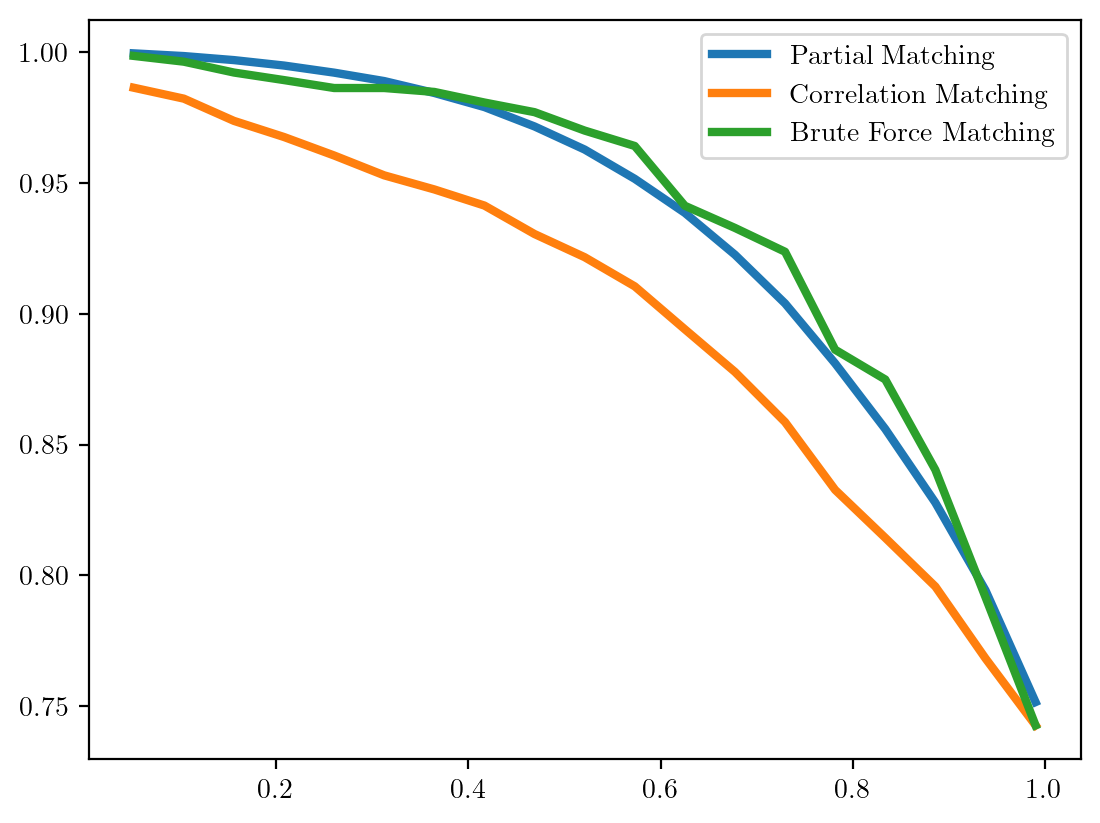

In [26]:
# plot everything
plt.plot(mreg_values[1:], aligment_scores_partial[1:], linestyle='-', linewidth=3., label='Partial Matching')
plt.plot(mreg_values[1:], alignment_scores_correlation[1:], linestyle='-', linewidth=3., label='Correlation Matching')
plt.plot(mreg_values[1:], alignment_scores_brute_force[1:], linestyle='-', linewidth=3., label='Brute Force Matching')
plt.legend()
plt.show()

# repeat for all layers

In [12]:
layers_to_use = [norm_layer0, norm_layer_half, norm_layer_end]
results_dict = {l: {'partial_matching': None, 
                    'correlation_ordering': None,
                    'brute_force_matching': None} 
                for l in layers_to_use}

for layer in layers_to_use:
    # get activations
    activations_s1 = get_activations(model=resnet18_s1.to(f'cuda:{device_id}'), 
                                 dloader=in1k_dataloader, 
                                 layer_name=layer, 
                                 device_id=device_id)
    activations_s2 = get_activations(model=resnet18_s2.to(f'cuda:{device_id}'), 
                                 dloader=in1k_dataloader, 
                                 layer_name=layer, 
                                 device_id=device_id)

    # align conv layers using different alignment strategies
    # partial matching
    mreg_dict_partial = align_responses_unbalanced(activations_s1, activations_s2)
    mreg_values = np.array(sorted(mreg_dict_partial.keys()))
    aligment_scores_partial = np.array([mreg_dict_partial[m]['score'] for m in mreg_values])
    
    # correlating ordering
    mreg_dict_correlation = align_responses_with_soft_match(activations_s1, activations_s2)
    mreg_dict_correlation = order_with_correlations(mreg_dict=mreg_dict_correlation,
                                                    transform_thresh=1e-8,
                                                    activations1=activations_s1, 
                                                    activations2=activations_s2)
    alignment_scores_correlation = np.array([mreg_dict_correlation[m]['sm_score'] for m in mreg_values])
    
    # brute-force ordering
    delta_dict_forward = brute_force_matching(activations_s1, activations_s2)
    delta_dict_backward = brute_force_matching(activations_s2, activations_s1)
    mreg_dict_brute_force = align_responses_with_soft_match(activations_s1, activations_s2)
    mreg_dict_brute_force = order_with_brute_force(mreg_dict=mreg_dict_brute_force,
                                                   delta_dicts=(delta_dict_forward, delta_dict_backward), 
                                                   transform_thresh=1e-8, 
                                                   activations1=activations_s1, 
                                                   activations2=activations_s2)
    alignment_scores_brute_force = np.array([mreg_dict_brute_force[m]['sm_score'] for m in mreg_values])

    # append results to dictionary
    results_dict[layer]['partial_matching'] = aligment_scores_partial
    results_dict[layer]['correlation_ordering'] = alignment_scores_correlation
    results_dict[layer]['brute_force_ordering'] = alignment_scores_brute_force

  0%|                                                                                                                                                                                                                  | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_1728917/3234712721.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(activations1), torch.tensor(activations2))))
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.93it/s]
/tmp/ipykernel_1728917/3022949311.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().req

score: 1
score: 0.9985259165987372
score: 0.9963186588138342
score: 0.992171673104167
score: 0.9892822382971644
score: 0.9862520219758153
score: 0.9862520219758153
score: 0.9847543742507696
score: 0.9807095229625702
score: 0.9770209453999996
score: 0.9699892066419125
score: 0.9641024693846703
score: 0.941249817609787
score: 0.9327835515141487
score: 0.923674575984478
score: 0.8862363547086716
score: 0.8748612254858017
score: 0.8403210341930389
score: 0.7917070686817169
score: 0.7426691651344299


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:06<00:00,  3.30it/s]


score: 1
score: 0.9847467551007867
score: 0.966278649866581
score: 0.9576055221259594
score: 0.9492902457714081
score: 0.9368052780628204
score: 0.8958990722894669
score: 0.8641269505023956
score: 0.838909924030304
score: 0.8158245235681534
score: 0.7889639735221863
score: 0.7654346376657486
score: 0.7316385209560394
score: 0.7016117572784424
score: 0.6600668430328369
score: 0.604196697473526
score: 0.5657703876495361
score: 0.5132337808609009
score: 0.4421653151512146
score: 0.36785757541656494


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:33<00:00,  1.68s/it]


score: 1
score: 0.9892754144966602
score: 0.9733634144067764
score: 0.9527487568557262
score: 0.9367842823266983
score: 0.9107295870780945
score: 0.8919387608766556
score: 0.8641345500946045
score: 0.8358704596757889
score: 0.803098276257515
score: 0.7654053568840027
score: 0.7376000881195068
score: 0.6977850794792175
score: 0.6509156227111816
score: 0.6050752103328705
score: 0.555540144443512
score: 0.5009158253669739
score: 0.43860167264938354
score: 0.3741788864135742
score: 0.30083155632019043


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 583.95it/s]


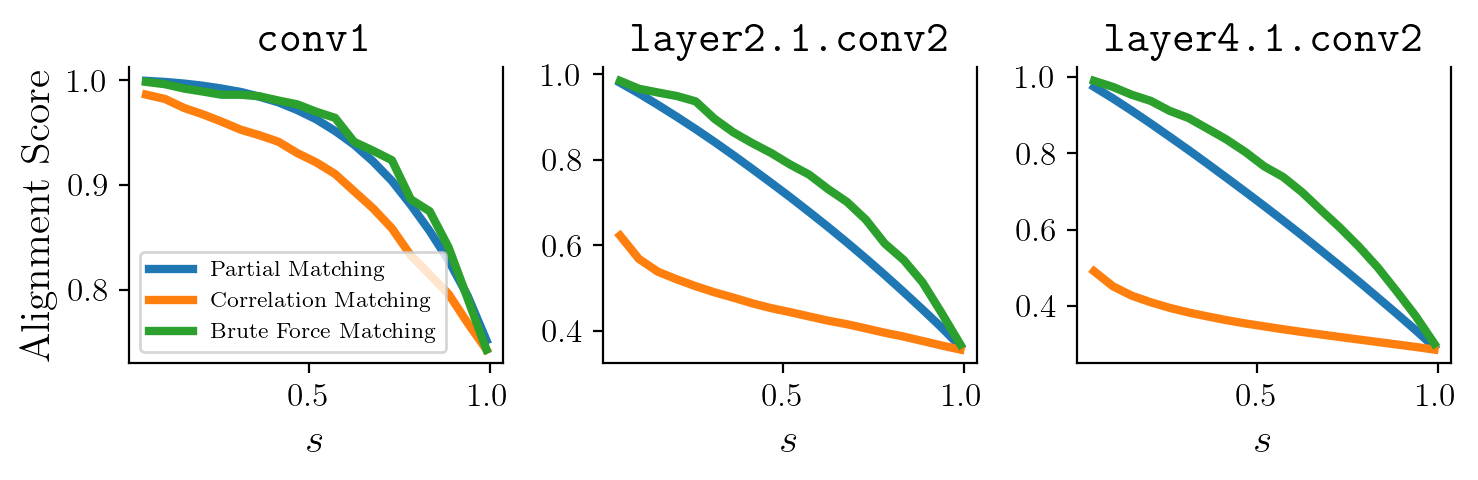

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6*1.25, 2*1.25))  
axes = axes.flatten()  

for i, layer in tqdm(enumerate(layers_to_use), total=len(layers_to_use)):
    layer_results = results_dict[layer]
    partial_matching_dict = layer_results['partial_matching'][1:]
    corr_dict = layer_results['correlation_ordering'][1:]
    brute_force_dict = layer_results['brute_force_ordering'][1:]

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    
    #axes[i].set_xlabel(r'$m_\mathrm{reg}$', fontsize=15)
    axes[i].set_xlabel(r'$s$', fontsize=15)
    if i == 0 or i == 3:
        axes[i].set_ylabel('Alignment Score', fontsize=15)
    axes[i].plot(mreg_values[1:], partial_matching_dict, linestyle='-', linewidth=3., label='Partial Matching')
    axes[i].plot(mreg_values[1:], corr_dict, linestyle='-', linewidth=3., label='Correlation Matching')
    axes[i].plot(mreg_values[1:], brute_force_dict, linestyle='-', linewidth=3., label='Brute Force Matching')
    axes[i].tick_params(axis='both', labelsize=12)
    ax1.spines['top'].set_visible(False)

    # brain region name
    #axes[i].set_title(layer, fontsize=16, fontweight='bold')
    axes[i].set_title(r'\texttt{' + layer.replace('_', r'\_') + r'}', fontsize=16)

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = axes[i].get_legend_handles_labels()
        axes[i].legend(lines1, labels1, loc='best', fontsize=8)

fig.tight_layout()
plt.savefig(f'./paper-figures/resnet18-matching-baselines-in1k.png', dpi=300)
plt.show()

# repeat with euclidean cost

In [11]:
layers_to_use = [norm_layer0, norm_layer_half, norm_layer_end]
results_dict = {l: {'partial_matching': None, 
                    'correlation_ordering': None,
                    'brute_force_matching': None} 
                for l in layers_to_use}

for layer in layers_to_use:
    # get activations
    activations_s1 = get_activations(model=resnet18_s1.to(f'cuda:{device_id}'), 
                                 dloader=in1k_dataloader, 
                                 layer_name=layer, 
                                 device_id=device_id)
    activations_s2 = get_activations(model=resnet18_s2.to(f'cuda:{device_id}'), 
                                 dloader=in1k_dataloader, 
                                 layer_name=layer, 
                                 device_id=device_id)

    # align conv layers using different alignment strategies
    # partial matching
    mreg_dict_partial = align_responses_unbalanced(activations_s1, activations_s2, cost_type='euclidean')
    mreg_values = np.array(sorted(mreg_dict_partial.keys()))
    aligment_scores_partial = np.array([mreg_dict_partial[m]['score'] for m in mreg_values])
    
    # correlating ordering
    mreg_dict_correlation = align_responses_with_soft_match(activations_s1, activations_s2, cost_type='euclidean')
    mreg_dict_correlation = order_with_correlations(mreg_dict=mreg_dict_correlation,
                                                    transform_thresh=1e-8,
                                                    activations1=activations_s1, 
                                                    activations2=activations_s2, 
                                                    cost_type='euclidean')
    alignment_scores_correlation = np.array([mreg_dict_correlation[m]['sm_score'] for m in mreg_values])
    
    # brute-force ordering
    delta_dict_forward = brute_force_matching(activations_s1, activations_s2, cost_type='euclidean')
    delta_dict_backward = brute_force_matching(activations_s2, activations_s1, cost_type='euclidean')
    mreg_dict_brute_force = align_responses_with_soft_match(activations_s1, activations_s2, cost_type='euclidean')
    mreg_dict_brute_force = order_with_brute_force(mreg_dict=mreg_dict_brute_force,
                                                   delta_dicts=(delta_dict_forward, delta_dict_backward), 
                                                   transform_thresh=1e-8, 
                                                   activations1=activations_s1, 
                                                   activations2=activations_s2, 
                                                   cost_type='euclidean')
    alignment_scores_brute_force = np.array([mreg_dict_brute_force[m]['sm_score'] for m in mreg_values])

    # append results to dictionary
    results_dict[layer]['partial_matching'] = aligment_scores_partial
    results_dict[layer]['correlation_ordering'] = alignment_scores_correlation
    results_dict[layer]['brute_force_ordering'] = alignment_scores_brute_force

  0%|                                                                                                                                                               | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_3211288/2831160088.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(activations1), torch.tensor(activations2))))
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  5.46it/s]
/tmp/ipykernel_3211288/1236054135.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sm_score = np.mean(np.array(soft_match.fi

score: 1
score: -903.4865112304688
score: -1840.94384765625
score: -2146.86181640625
score: -2811.0849609375
score: -2942.43017578125
score: -3039.571533203125
score: -3316.92431640625
score: -4218.509765625
score: -4384.76220703125
score: -4818.27734375
score: -5432.32421875
score: -6437.6767578125
score: -7760.09423828125
score: -9116.96875
score: -11213.125
score: -13095.9033203125
score: -14753.9716796875
score: -19692.201171875
score: -23881.71875


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.70it/s]


score: 1
score: -13.616596221923828
score: -18.632726669311523
score: -24.30693244934082
score: -33.82246780395508
score: -43.4299430847168
score: -57.16523361206055
score: -72.76875305175781
score: -87.36949157714844
score: -109.98271179199219
score: -129.42193603515625
score: -143.50665283203125
score: -164.98825073242188
score: -193.94032287597656
score: -233.36529541015625
score: -270.0103454589844
score: -304.80987548828125
score: -356.7710876464844
score: -419.7307434082031
score: -472.4210510253906


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.07it/s]


score: 1
score: -0.3339470624923706
score: -2.725922107696533
score: -5.574021339416504
score: -9.134883880615234
score: -13.378026008605957
score: -18.18850326538086
score: -22.796756744384766
score: -28.481306076049805
score: -36.55882263183594
score: -47.293540954589844
score: -59.06126403808594
score: -72.03166961669922
score: -81.97724151611328
score: -95.05856323242188
score: -110.73780822753906
score: -128.43475341796875
score: -147.94676208496094
score: -166.638916015625
score: -188.4098663330078


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 279.12it/s]


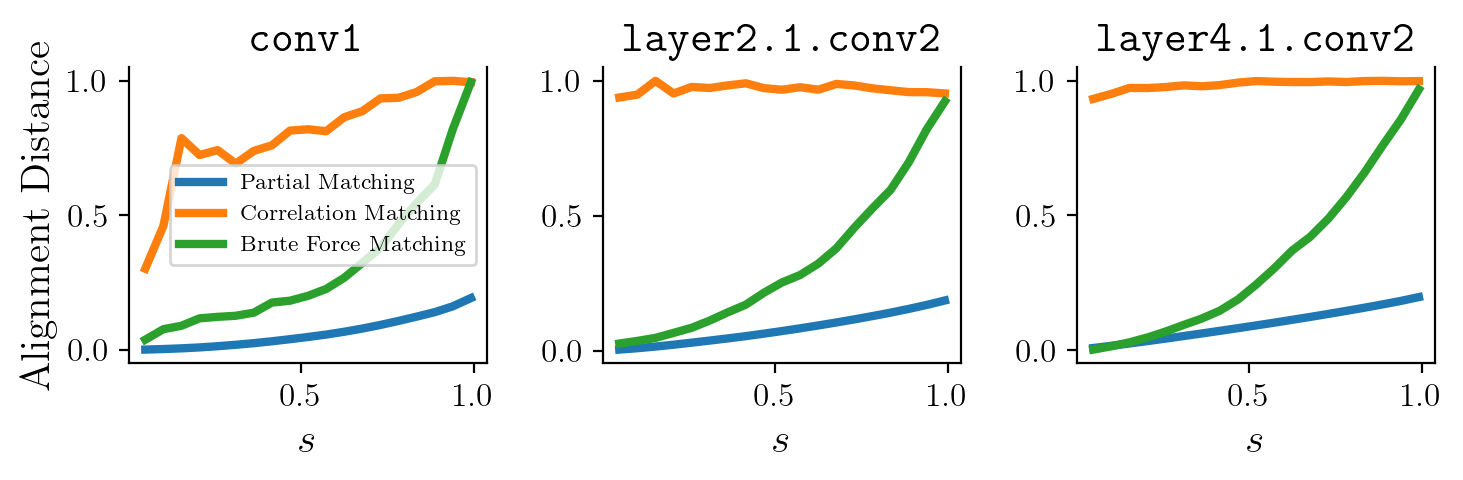

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(6*1.25, 2*1.25))  
axes = axes.flatten()  

for i, layer in tqdm(enumerate(layers_to_use), total=len(layers_to_use)):
    layer_results = results_dict[layer]
    partial_matching_dict = layer_results['partial_matching'][1:]
    corr_dict = layer_results['correlation_ordering'][1:]
    brute_force_dict = layer_results['brute_force_ordering'][1:]

    # find max
    max_partial = max(partial_matching_dict)
    max_corr = max(corr_dict)
    max_brute = max(brute_force_dict)
    norm_factor = max(max_partial, max_corr, max_brute)

    # rescale
    partial_matching_dict = partial_matching_dict / norm_factor
    corr_dict = corr_dict / norm_factor
    brute_force_dict = -brute_force_dict / norm_factor

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    
    #axes[i].set_xlabel(r'$m_\mathrm{reg}$', fontsize=15)
    axes[i].set_xlabel(r'$s$', fontsize=15)
    if i == 0 or i == 3:
        axes[i].set_ylabel('Alignment Distance', fontsize=15)
    axes[i].plot(mreg_values[1:], partial_matching_dict, linestyle='-', linewidth=3., label='Partial Matching')
    axes[i].plot(mreg_values[1:], corr_dict, linestyle='-', linewidth=3., label='Correlation Matching')
    axes[i].plot(mreg_values[1:], brute_force_dict, linestyle='-', linewidth=3., label='Brute Force Matching')
    axes[i].tick_params(axis='both', labelsize=12)
    ax1.spines['top'].set_visible(False)

    # brain region name
    #axes[i].set_title(layer, fontsize=16, fontweight='bold')
    axes[i].set_title(r'\texttt{' + layer.replace('_', r'\_') + r'}', fontsize=16)

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = axes[i].get_legend_handles_labels()
        axes[i].legend(lines1, labels1, loc='best', fontsize=8)

fig.tight_layout()
plt.savefig(f'./paper-figures/resnet18-matching-baselines-in1k-euclidean.png', dpi=300)
plt.show()